<a href="https://colab.research.google.com/github/ScholarlyInsane/ml-practice/blob/main/soilfertility.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('soil_fertility.csv')

print("First 5 rows of the DataFrame:")
print(df.head())

print("\nDataFrame Information:")
df.info()

First 5 rows of the DataFrame:
     N    P    K    pH    EC    OC     S    Zn    Fe    Cu    Mn     B  Output
0  138  8.6  560  7.46  0.62  0.70   5.9  0.24  0.31  0.77  8.71  0.11       0
1  213  7.5  338  7.62  0.75  1.06  25.4  0.30  0.86  1.54  2.89  2.29       0
2  163  9.6  718  7.59  0.51  1.11  14.3  0.30  0.86  1.57  2.70  2.03       0
3  157  6.8  475  7.64  0.58  0.94  26.0  0.34  0.54  1.53  2.65  1.82       0
4  270  9.9  444  7.63  0.40  0.86  11.8  0.25  0.76  1.69  2.43  2.26       1

DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 880 entries, 0 to 879
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   N       880 non-null    int64  
 1   P       880 non-null    float64
 2   K       880 non-null    int64  
 3   pH      880 non-null    float64
 4   EC      880 non-null    float64
 5   OC      880 non-null    float64
 6   S       880 non-null    float64
 7   Zn      880 non-null    floa

In [ ]:
df.shape

(880, 13)

Descriptive Statistics of the DataFrame:
               N           P           K          pH          EC          OC  \
count  880.00000  880.000000  880.000000  880.000000  880.000000  880.000000   
mean   246.73750   14.562159  499.978409    7.510500    0.543659    0.617989   
std     77.38886   21.967755  124.222838    0.464912    0.141597    0.842986   
min      6.00000    2.900000   11.000000    0.900000    0.100000    0.100000   
25%    201.00000    6.800000  412.000000    7.350000    0.430000    0.380000   
50%    257.00000    8.100000  475.000000    7.500000    0.545000    0.590000   
75%    307.00000   10.550000  581.000000    7.630000    0.640000    0.780000   
max    383.00000  125.000000  887.000000   11.150000    0.950000   24.000000   

                S          Zn          Fe          Cu          Mn           B  \
count  880.000000  880.000000  880.000000  880.000000  880.000000  880.000000   
mean     7.545080    0.469273    4.140523    0.952443    8.666500    0.59015

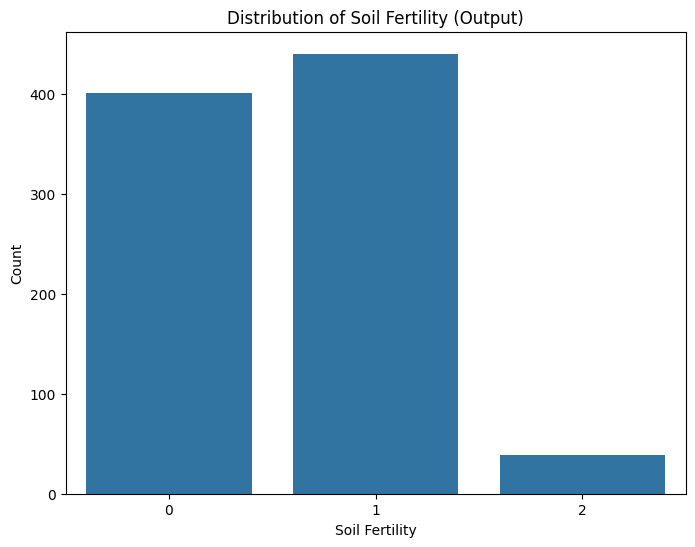

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Descriptive Statistics of the DataFrame:")
print(df.describe())

plt.figure(figsize=(8, 6))
sns.countplot(x='Output', data=df)
plt.title('Distribution of Soil Fertility (Output)')
plt.xlabel('Soil Fertility')
plt.ylabel('Count')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df.drop('Output', axis=1)
y = df['Output']

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("\nFirst 5 rows of scaled features (X_scaled):")
print(X_scaled_df.head())

Shape of features (X): (880, 12)
Shape of target (y): (880,)

First 5 rows of scaled features (X_scaled):
          N         P         K        pH        EC        OC         S  \
0 -1.405879 -0.271559  0.483452 -0.108684  0.539450  0.097342 -0.372049   
1 -0.436196 -0.321661 -1.304676  0.235662  1.458073  0.524638  4.038050   
2 -1.082651 -0.226012  1.756083  0.171097 -0.237846  0.583985  1.527686   
3 -1.160226 -0.353544 -0.201192  0.278706  0.256797  0.382206  4.173745   
4  0.300763 -0.212348 -0.450885  0.257184 -1.015142  0.287251  0.962288   

         Zn        Fe        Cu        Mn         B  
0 -0.121106 -1.232375 -0.391816  0.010125 -0.841681  
1 -0.089413 -1.055427  1.261840 -1.344503  2.979688  
2 -0.089413 -1.055427  1.326268 -1.388726  2.523929  
3 -0.068284 -1.158379  1.240364 -1.400363  2.155815  
4 -0.115824 -1.087599  1.583981 -1.451569  2.927101  


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (704, 12)
Shape of X_test: (176, 12)
Shape of y_train: (704,)
Shape of y_test: (176,)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

lr_model = LogisticRegression(max_iter=200, random_state=42)
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)
nb_model=GaussianNB()
knn_model=KNeighborsClassifier()

print("Training Logistic Regression Model...")
lr_model.fit(X_train, y_train)
print("Logistic Regression Model Trained.")

print("\nTraining Decision Tree Classifier Model...")
dt_model.fit(X_train, y_train)
print("Decision Tree Classifier Model Trained.")

print("\nTraining Random Forest Classifier Model...")
rf_model.fit(X_train, y_train)
print("Random Forest Classifier Model Trained.")

print("\nTraining Naive Bayes Model...")
nb_model.fit(X_train, y_train)
print("Naive Bayes Model Trained.")

print("\nTraining KNN Model...")
knn_model.fit(X_train, y_train)
print("KNN Model Trained.")


Training Logistic Regression Model...
Logistic Regression Model Trained.

Training Decision Tree Classifier Model...
Decision Tree Classifier Model Trained.

Training Random Forest Classifier Model...
Random Forest Classifier Model Trained.

Training Naive Bayes Model...
Naive Bayes Model Trained.

Training KNN Model...
KNN Model Trained.


In [ ]:
from sklearn.metrics import accuracy_score

y_pred_lr = lr_model.predict(X_test)
y_pred_dt = dt_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_nb= nb_model.predict(X_test)
y_pred_knn=knn_model.predict(X_test)

print("Model Accuracy Scores:")
print(f"Logistic Regression: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Decision Tree Classifier: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Random Forest Classifier: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Naive Bayes: {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"KNN: {accuracy_score(y_test, y_pred_knn):.4f}")


Model Accuracy Scores:
Logistic Regression: 0.8352
Decision Tree Classifier: 0.8352
Random Forest Classifier: 0.8864
Naive Bayes: 0.4602
KNN: 0.7273


In [ ]:
model_accuracies = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Decision Tree Classifier": accuracy_score(y_test, y_pred_dt),
    "Random Forest Classifier": accuracy_score(y_test, y_pred_rf),
    "Naive Bayes": accuracy_score(y_test, y_pred_nb),
    "KNN": accuracy_score(y_test, y_pred_knn)
}

print("\n--- Model Accuracy Comparison ---")
for model_name, accuracy in model_accuracies.items():
    print(f"{model_name}: {accuracy:.4f}")

best_model_name = max(model_accuracies, key=model_accuracies.get)
best_accuracy = model_accuracies[best_model_name]

print(f"\nBased on accuracy scores, the best-performing model is: {best_model_name} with an accuracy of {best_accuracy:.4f}")


--- Model Accuracy Comparison ---
Logistic Regression: 0.8352
Decision Tree Classifier: 0.8352
Random Forest Classifier: 0.8864
Naive Bayes: 0.4602
KNN: 0.7273

Based on accuracy scores, the best-performing model is: Random Forest Classifier with an accuracy of 0.8864


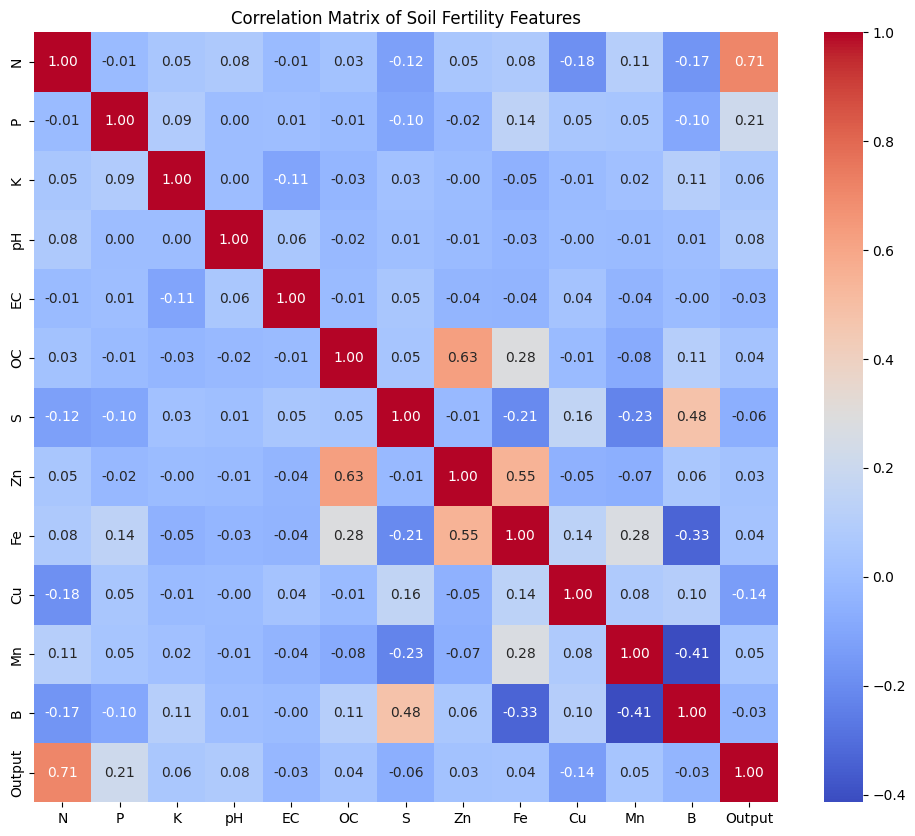

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Soil Fertility Features')
plt.show()

/tmp/ipykernel_1014/473083078.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Output', y='N', data=df, ax=axes[0, 0], palette='viridis')
/tmp/ipykernel_1014/473083078.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Output', y='P', data=df, ax=axes[0, 1], palette='viridis')
/tmp/ipykernel_1014/473083078.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Output', y='K', data=df, ax=axes[1, 0], palette='viridis')
/tmp/ipykernel_1014/473083078.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and 

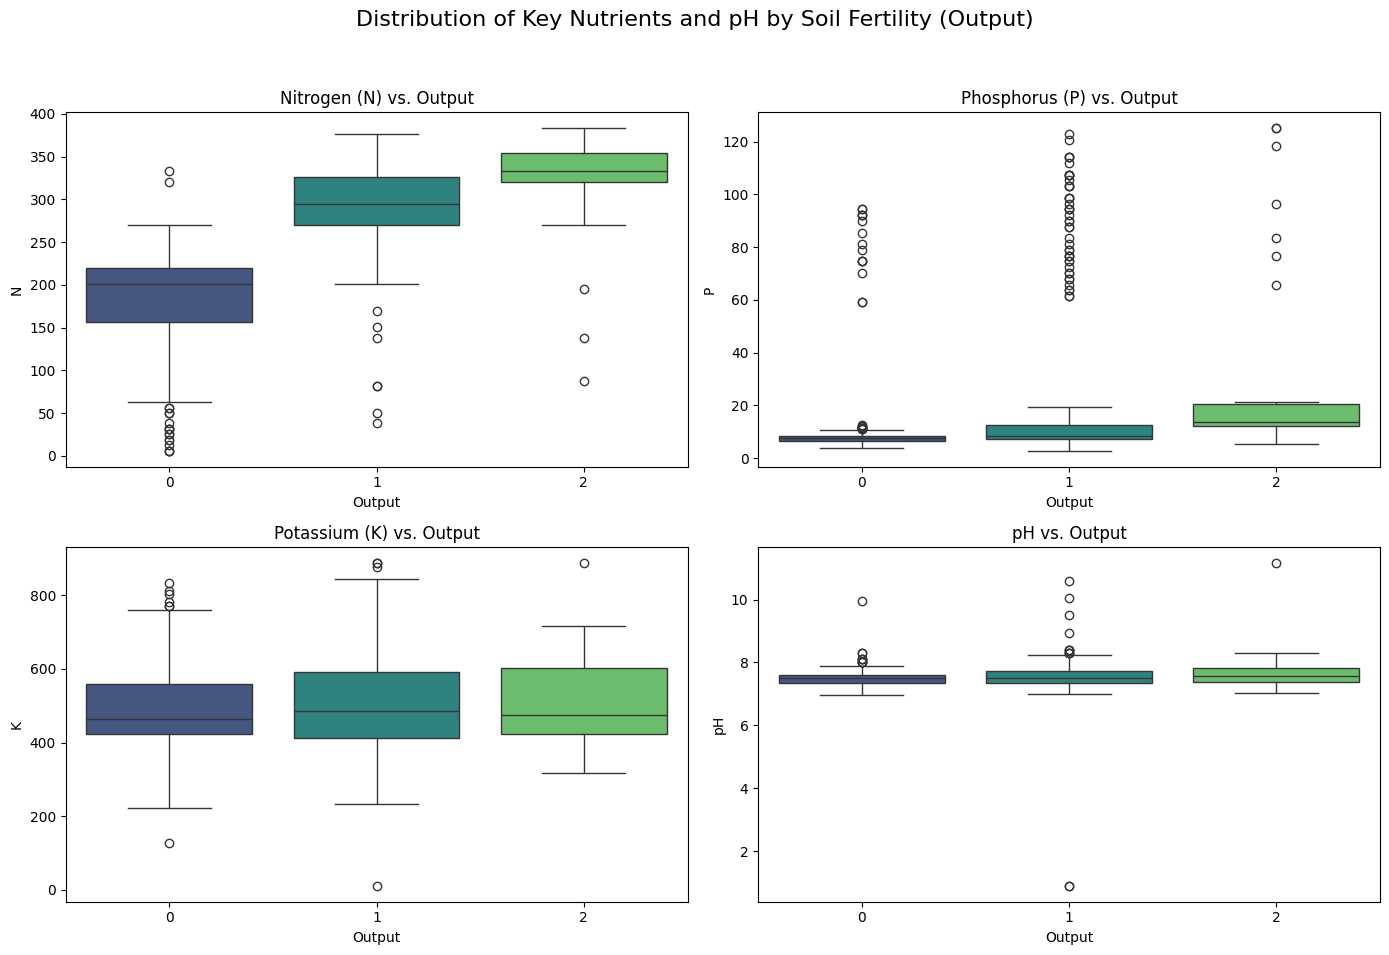

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Key Nutrients and pH by Soil Fertility (Output)', fontsize=16)

sns.boxplot(x='Output', y='N', data=df, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Nitrogen (N) vs. Output')

sns.boxplot(x='Output', y='P', data=df, ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Phosphorus (P) vs. Output')

sns.boxplot(x='Output', y='K', data=df, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Potassium (K) vs. Output')

sns.boxplot(x='Output', y='pH', data=df, ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('pH vs. Output')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]
    df_clean = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

    print(f"Column: {column}")
    print(f"Outliers removed: {len(outliers)}")
    print(f"Original data points: {len(df)}, Clean data points: {len(df_clean)}")
    print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}\n")

    return df_clean, outliers

df_clean = df.copy()
outliers_count = {}


In [ ]:
print(f"Shape of original DataFrame: {df.shape}")

numerical_cols = df.drop(columns=['Output']).select_dtypes(include=['number']).columns

overall_mask = pd.Series([True] * len(df), index=df.index)

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    col_mask = (df[col] >= lower_bound) & (df[col] <= upper_bound)
    overall_mask = overall_mask & col_mask

df_no_outliers = df[overall_mask]

print(f"Shape of DataFrame after outlier removal: {df_no_outliers.shape}")

Shape of original DataFrame: (880, 13)
Shape of DataFrame after outlier removal: (623, 13)


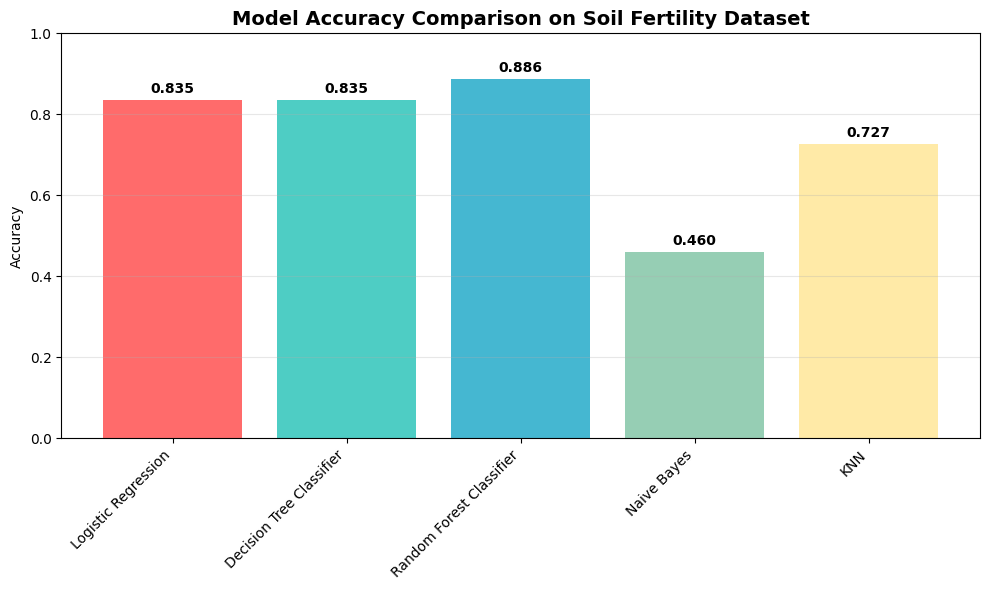

Model Accuracies:
Logistic Regression: 0.8352
Decision Tree Classifier: 0.8352
Random Forest Classifier: 0.8864
Naive Bayes: 0.4602
KNN: 0.7273


In [ ]:
accuracies = {}

models = {
    "Logistic Regression": lr_model,
    "Decision Tree Classifier": dt_model,
    "Random Forest Classifier": rf_model,
    "Naive Bayes": nb_model,
    "KNN": knn_model
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracies[name] = accuracy_score(y_test, y_pred)

plt.figure(figsize=(10, 6))
models_names = list(accuracies.keys())
accuracy_values = list(accuracies.values())

bars = plt.bar(models_names, accuracy_values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'])
plt.title('Model Accuracy Comparison on Soil Fertility Dataset', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

for bar, acc in zip(bars, accuracy_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("Model Accuracies:")
for name, acc in accuracies.items():
    print(f"{name}: {acc:.4f}")

In [ ]:
print("Minimum and Maximum values for key soil features:")
print(f"N (Nitrogen): Min = {df['N'].min():.2f}, Max = {df['N'].max():.2f}")
print(f"P (Phosphorus): Min = {df['P'].min():.2f}, Max = {df['P'].max():.2f}")
print(f"K (Potassium): Min = {df['K'].min():.2f}, Max = {df['K'].max():.2f}")
print(f"pH (Soil pH): Min = {df['pH'].min():.2f}, Max = {df['pH'].max():.2f}")

Minimum and Maximum values for key soil features:
N (Nitrogen): Min = 6.00, Max = 383.00
P (Phosphorus): Min = 2.90, Max = 125.00
K (Potassium): Min = 11.00, Max = 887.00
pH (Soil pH): Min = 0.90, Max = 11.15


In [ ]:
n_input = float(input("Enter the value for N (Nitrogen): "))
p_input = float(input("Enter the value for P (Phosphorus): "))
k_input = float(input("Enter the value for K (Potassium): "))
ph_input = float(input("Enter the value for pH (Soil pH): "))

print(f"\nInput values:\nN: {n_input}\nP: {p_input}\nK: {k_input}\npH: {ph_input}")

Enter the value for N (Nitrogen): 54
Enter the value for P (Phosphorus): 256
Enter the value for K (Potassium): 1254
Enter the value for pH (Soil pH): 5.6

Input values:
N: 54.0
P: 256.0
K: 1254.0
pH: 5.6


In [ ]:
user_input_df = pd.DataFrame({
    'N': [n_input],
    'P': [p_input],
    'K': [k_input],
    'pH': [ph_input]
})

all_features = X.columns

for feature in all_features:
    if feature not in user_input_df.columns:
        user_input_df[feature] = X[feature].mean()

user_input_df = user_input_df[all_features]

user_input_scaled = scaler.transform(user_input_df)

print("Processed and scaled user input:")
print(pd.DataFrame(user_input_scaled, columns=all_features).head())

Processed and scaled user input:
          N          P         K        pH   EC   OC    S   Zn   Fe   Cu   Mn  \
0 -2.491923  10.996806  6.073363 -4.111715  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

     B  
0  0.0  


In [ ]:
predicted_fertility = rf_model.predict(user_input_scaled)

print(f"\nPredicted Soil Fertility Class: {predicted_fertility[0]}")


Predicted Soil Fertility Class: 0
